# Distribution of peak LFC according to differential binding analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


from matplotlib import font_manager
import matplotlib as mpl

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'
import warnings
warnings.filterwarnings("ignore")

In [2]:
def plot_distribution(df_path, contrast_col, logfc_col, title, xlim=(-1, 1)):
	df  = pd.read_csv(df_path, sep="\t")
	df = df[(df["MACS.logP"] >= -np.log10(1e-05)) & (df["coverage"] >= 30)]
	df["Contrast"] = df[contrast_col].str.partition("_vs_")[0]
	df["neg_log10_PValue"] = -np.log10(df["PValue"])

	# LFC dist
	color_map = {
		"SCC2": "#258FC7",
		"SCC5": "#107F80",
		"723": "#258FC7",
		"723_2": "#107F80"
	}

	plt.figure(figsize=(4, 2))
	sns.kdeplot(
		data=df, 
		x=logfc_col, 
		hue=contrast_col, 
		palette=color_map,
		fill=False, 
		common_norm=False,
		legend=True
		)
	for group, group_df in df.groupby(contrast_col, observed=True):
		median_value = group_df[logfc_col].median()

		plt.axvline(
			median_value,
			color=color_map[group],
			linewidth=1,
			linestyle="--",
			label="_nolegend_"  # Avoid duplicate legend entries
		)
	plt.xlim(xlim)
	plt.title(title, fontsize=13)
	plt.xlabel(r"$\log_2$(fold change)", fontsize=12)
	plt.ylabel("Density", fontsize=12)
	plt.xticks([xlim[0], 0, xlim[1]], fontsize=10)
	plt.yticks([0, 1], fontsize=10)
	plt.axvline(0, color='grey', linewidth=0.5, linestyle='--')
	ax = plt.gca()
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	sns.move_legend(ax, "upper right", frameon=False, fontsize=12)
	ax.legend_.set_title(None)
	plt.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/miscellaneous/ChIP_lfc_dist.{title}.nobl.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	plt.show()

	# H0​:LFC distribution is centered at 0HA​:LFC distribution is shifted below 0
	test_results = []

	for contrast, group_df in df.groupby(contrast_col, observed=True):
		values = (group_df[logfc_col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy())

		# Wilcoxon cannot test a sample containing only zeros
		if len(values) == 0 or np.all(values == 0):
			statistic = np.nan
			p_value = np.nan
		else:
			result = wilcoxon(
				values,
				alternative="less",
				zero_method="wilcox",
				method="auto"
			)
			statistic = result.statistic
			p_value = result.pvalue

		test_results.append({
			contrast_col: contrast,
			"n": len(values),
			"median_LFC": np.median(values) if len(values) else np.nan,
			"wilcoxon_statistic": statistic,
			"p_value": p_value
		})

	test_results = pd.DataFrame(test_results)
	print(test_results)

	# volcano plots, y-axis being PValue
	for contrast in df[contrast_col].unique():
		subset = df[df["Contrast"] == contrast]
		colors = np.where(
			subset["logFC"] > 0,
			"#FF9FC5",   
			"#9BDEFD"    
		)
		n_positive = (subset["logFC"] > 0).sum()
		n_negative = (subset["logFC"] < 0).sum()
		subset["plot_neg_log10_PValue"] = subset["neg_log10_PValue"].clip(0, 6)
		fig, ax = plt.subplots(figsize=(2, 3))
		ax.scatter(
			subset["logFC"],
			subset["plot_neg_log10_PValue"],
			s=4,
			c=colors,
			alpha=1,
			edgecolors="none",
			rasterized=True
		)
		ax.text(
			0.03,
			0.97,
			f"{n_negative:,}",
			transform=ax.transAxes,
			ha="left",
			va="top",
			fontsize=11,
			color="#0099E6"
		)

		ax.text(
			0.97,
			0.97,
			f"{n_positive:,}",
			transform=ax.transAxes,
			ha="right",
			va="top",
			fontsize=11,
			color="#D90057"
		)
		ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
		ax.set_ylim(0, 6)
		ax.set_xlabel(r"$\log_2$(fold change)", fontsize=12)
		ax.set_ylabel(r"$-\log_{10}$($p$ value)", fontsize=12)
		ax.set_title(f"{title} {contrast}", fontsize=12)
		ax.tick_params(axis="both", labelsize=12)
		ax.spines["top"].set_visible(False)
		ax.spines["right"].set_visible(False)
		ax.grid(False)
		fig.tight_layout()
		plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/miscellaneous/ChIP_volcano.{contrast}.nobl.pdf", 
					bbox_inches="tight",
					dpi=300,              
					transparent=True,
					format='pdf')
		plt.show()

		# plot_df = subset.loc[
		# 	np.isfinite(subset["logCPM"]) & np.isfinite(subset["logFC"]),
		# 	["logCPM", "logFC"]
		# ].copy()

		# fig, ax = plt.subplots(figsize=(7, 5))

		# hb = ax.hexbin(
		# 	plot_df["logCPM"],
		# 	plot_df["logFC"],
		# 	gridsize=60,
		# 	mincnt=1,
		# 	bins="log"
		# )

		# ax.axhline(0, linestyle="--", linewidth=1)

		# ax.set(
		# 	title="MA plot",
		# 	xlabel="Average expression (logCPM)",
		# 	ylabel="Log2 fold change"
		# )

		# cbar = fig.colorbar(hb, ax=ax)
		# cbar.set_label("log10(number of genes)")

		# plt.tight_layout()
		# plt.show()

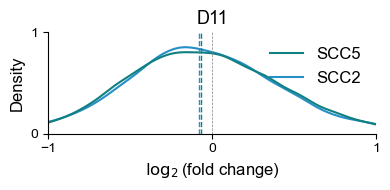

  Contrast      n  median_LFC  wilcoxon_statistic       p_value
0     SCC2  19682   -0.078557          81423436.0  9.642298e-84
1     SCC5  19682   -0.068901          83835318.0  3.163326e-60


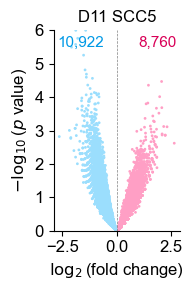

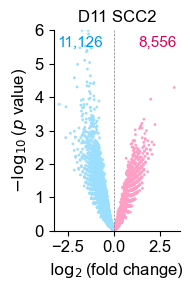

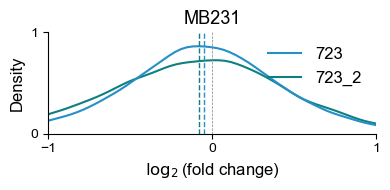

  Contrast      n  median_LFC  wilcoxon_statistic       p_value
0      723  16671   -0.051166          61318338.0  9.468368e-40
1    723_2  16671   -0.077612          57361927.0  4.617143e-85


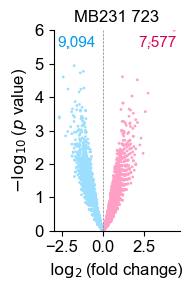

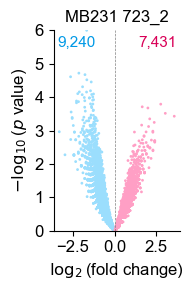

In [3]:
plot_distribution(
	"/media/scratch/fy2306/projects/base_editing/results/ChIP-Seq/D11_all_contrasts.nobl.tsv", 
	"Contrast", 
	"logFC", 
	"D11")
plot_distribution(
	"/media/scratch/fy2306/projects/base_editing/results/ChIP-Seq/MB231_all_contrasts.nobl.tsv", 
	"Contrast", 
	"logFC", 
	"MB231")